In [1]:
from typing import TypedDict

from langchain_core.runnables import RunnableConfig
from langgraph import graph
from langgraph.graph import StateGraph,START,END
from langgraph.errors import GraphRecursionError
from loguru import  logger

#1. 声明状态
class EmptyState(TypedDict):
    pass

#2. 声明节点
def loop_node(state:EmptyState,config:RunnableConfig) -> EmptyState:
    # 获取当前的超步数
    cur_step = config["metadata"]["langgraph_step"]
    logger.info("loop_node,cur_step:{}",cur_step)


#3. 构建图
builder = StateGraph(state_schema=EmptyState)
builder.add_node("loop_node",loop_node)
builder.add_edge(START,"loop_node")
builder.add_edge("loop_node","loop_node")
graph = builder.compile()

try:
    graph.invoke({},config={"recursion_limit":10})
except GraphRecursionError as e:
    logger.info("超步数量达到最大限制,抛出异常:{}",e)



2026-07-06 09:54:42.182 | INFO     | __main__:loop_node:17 - loop_node,cur_step:1
2026-07-06 09:54:42.183 | INFO     | __main__:loop_node:17 - loop_node,cur_step:2
2026-07-06 09:54:42.184 | INFO     | __main__:loop_node:17 - loop_node,cur_step:3
2026-07-06 09:54:42.184 | INFO     | __main__:loop_node:17 - loop_node,cur_step:4
2026-07-06 09:54:42.185 | INFO     | __main__:loop_node:17 - loop_node,cur_step:5
2026-07-06 09:54:42.186 | INFO     | __main__:loop_node:17 - loop_node,cur_step:6
2026-07-06 09:54:42.186 | INFO     | __main__:loop_node:17 - loop_node,cur_step:7
2026-07-06 09:54:42.187 | INFO     | __main__:loop_node:17 - loop_node,cur_step:8
2026-07-06 09:54:42.188 | INFO     | __main__:loop_node:17 - loop_node,cur_step:9
2026-07-06 09:54:42.189 | INFO     | __main__:loop_node:17 - loop_node,cur_step:10
2026-07-06 09:54:42.189 | INFO     | __main__:<module>:30 - 超步数量达到最大限制,抛出异常:Recursion limit of 10 reached without hitting a stop condition. You can increase the limit by setting t

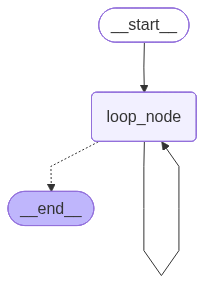

In [2]:
from IPython.display import display
display(graph)